In [6]:
pip install pandas 


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd 


# DATA CREATION

In [65]:
import os

print(os.getcwd())

/home/8e7da375-1215-4ce7-8157-c0b4225d40b7/Main_Project


In [66]:
import os

print(os.listdir())

['Feature_extraction.ipynb', 'ElectricalResistivity.csv', '.ipynb_checkpoints', 'Main_Data.csv', 'ElectricalConductivity.csv', 'ThermalConductivity.csv', 'violin_plot.png', 'Data_preparation.ipynb', 'PowerFactor.csv', 'SeebeckCoefficient.csv', 'Cleaned_Data.csv', 'ZT.csv']


In [67]:
#load
s = pd.read_csv("SeebeckCoefficient.csv")
tc = pd.read_csv("ThermalConductivity.csv")
zt = pd.read_csv("ZT.csv")
er = pd.read_csv("ElectricalResistivity.csv")

In [68]:
#rename the temperature column
s = s.rename(columns={"Unnamed: 0": "Temperature"})
tc = tc.rename(columns={"Unnamed: 0": "Temperature"})
zt = zt.rename(columns={"Unnamed: 0": "Temperature"})
er = er.rename(columns={"Unnamed: 0": "Temperature"})


* Here, all the data frames are in wide format.
* So, we need convert all of these long format.

In [69]:
zt # so it is the wide format


,Temperature,Pb0.95Ba0.04Na0.01Se1,Pb0.97Ba0.03Te1.01Na0.02,Pb1Cd0.01Te1.01Sb0.003,Pb0.7Mn0.3Te1Na0.04,Pb0.98Na0.02Te1ISW,K0.025Pb1Te0.7S0.3,Pb1Te1Na0.04,Pb1Te0.88S0.12,Pb1Hg0.03Te1.04Na0.02,...,Sn0.9975In0.0025Te1,Pb0.993Ga0.007Se1,Pb0.82Mn0.18Te1Na0.04,Pb0.96Ba0.04Te1.01Na0.02,In0.0025Sn0.9975Te0.99I0.01,In0.01Ag0.01Sn0.98Te1,Pb1Ca0.06Te1.07Na0.02,Na0.015Pb0.955Cd0.03Te1,Pb1Cd0.01Te1.01Sb0.06,Pb1.04Ca0.04S1
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,300,NaN,0.123215,NaN,NaN,NaN,NaN,NaN,0.598909,NaN,...,0.085904,NaN,NaN,0.158634,NaN,NaN,NaN,0.111039,NaN,NaN
7,350,0.044226,0.275372,NaN,0.276253,0.178594,0.287656,0.167435,0.898655,0.071634,...,0.111863,NaN,NaN,0.312611,0.052307,0.128595,0.190307,0.207030,0.054541,NaN
8,400,0.077134,0.446256,NaN,0.420050,0.322591,0.550884,0.300838,1.005583,0.140546,...,0.138243,NaN,NaN,0.469105,0.066872,0.153781,0.330926,0.339398,0.098820,NaN
9,450,0.125242,0.614292,NaN,0.563897,0.511127,0.906353,0.492499,1.074664,0.234127,...,0.169945,NaN,NaN,0.622561,0.088845,0.188217,0.504936,0.515654,0.158932,NaN


In [70]:
# wide --> long
s_long = s.melt(
    id_vars = "Temperature",
    var_name = "Formula",
    value_name = "SeebackCoefficient"
)

tc_long =tc.melt(
    id_vars = "Temperature",
    var_name = "Formula",
    value_name = "ThermalConductivity"
)

zt_long = zt.melt(
    id_vars = "Temperature",
    var_name = "Formula",
    value_name = "ZT"
)
er_long = er.melt(
    id_vars = "Temperature",
    var_name = "Formula",
    value_name = "ElectricalResistivity"
)

In [71]:
zt_long
#long format

,Temperature,Formula,ZT
0,0,Pb0.95Ba0.04Na0.01Se1,NaN
1,50,Pb0.95Ba0.04Na0.01Se1,NaN
2,100,Pb0.95Ba0.04Na0.01Se1,NaN
3,150,Pb0.95Ba0.04Na0.01Se1,NaN
4,200,Pb0.95Ba0.04Na0.01Se1,NaN
...,...,...,...
11270,1000,Pb1.04Ca0.04S1,NaN
11271,1050,Pb1.04Ca0.04S1,NaN
11272,1100,Pb1.04Ca0.04S1,NaN
11273,1150,Pb1.04Ca0.04S1,NaN


In [72]:
# merge
merged = pd.merge(
    s_long,
    er_long,
    on=["Formula", "Temperature"],
    how = "inner"
)

merged = pd.merge(
    merged,
    tc_long,
    on=["Formula", "Temperature"],
    how = "inner"
)

merged = pd.merge(
    merged,
    zt_long,
    on=["Formula", "Temperature"],
    how = "inner"
)

In [73]:
merged # this is the data set including the missing values.

,Temperature,Formula,SeebackCoefficient,ElectricalResistivity,ThermalConductivity,ZT
0,0,Pb0.95Ba0.04Na0.01Se1,NaN,NaN,NaN,NaN
1,50,Pb0.95Ba0.04Na0.01Se1,NaN,NaN,NaN,NaN
2,100,Pb0.95Ba0.04Na0.01Se1,NaN,NaN,NaN,NaN
3,150,Pb0.95Ba0.04Na0.01Se1,NaN,NaN,NaN,NaN
4,200,Pb0.95Ba0.04Na0.01Se1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
11270,1000,Pb1.04Ca0.04S1,NaN,NaN,NaN,NaN
11271,1050,Pb1.04Ca0.04S1,NaN,NaN,NaN,NaN
11272,1100,Pb1.04Ca0.04S1,NaN,NaN,NaN,NaN
11273,1150,Pb1.04Ca0.04S1,NaN,NaN,NaN,NaN


In [74]:
data = merged.dropna()
#after removing all the NaN or missing values.

In [75]:
len(data) 

1213

In [77]:
data

,Temperature,Formula,SeebackCoefficient,ElectricalResistivity,ThermalConductivity,ZT
82,350,Pb0.7Mn0.3Te1Na0.04,0.000186,0.000028,1.586099,0.276253
83,400,Pb0.7Mn0.3Te1Na0.04,0.000216,0.000032,1.412398,0.420050
84,450,Pb0.7Mn0.3Te1Na0.04,0.000243,0.000037,1.284120,0.563897
85,500,Pb0.7Mn0.3Te1Na0.04,0.000268,0.000044,1.168095,0.689989
86,550,Pb0.7Mn0.3Te1Na0.04,0.000289,0.000054,1.064337,0.799702
...,...,...,...,...,...,...
11211,550,Na0.015Pb0.955Cd0.03Te1,0.000197,0.000015,1.490776,0.982589
11212,600,Na0.015Pb0.955Cd0.03Te1,0.000218,0.000018,1.331080,1.228149
11213,650,Na0.015Pb0.955Cd0.03Te1,0.000234,0.000020,1.209305,1.438621
11214,700,Na0.015Pb0.955Cd0.03Te1,0.000242,0.000023,1.113275,1.587491


In [78]:
data["Formula"].nunique()

139

* So, For now the data:-
* There are total 1213 rows and 6 columns.
* And there 139 unique compounds.

In [104]:
import os

print(os.getcwd())  # current working directory


/home/8e7da375-1215-4ce7-8157-c0b4225d40b7/Main_Project


In [105]:
data.to_csv("/home/8e7da375-1215-4ce7-8157-c0b4225d40b7/Main_Project/Data.csv", index = False) 

In [80]:
print(data.columns)

Index(['Temperature', 'Formula', 'SeebackCoefficient', 'ElectricalResistivity',
       'ThermalConductivity', 'ZT'],
      dtype='object')


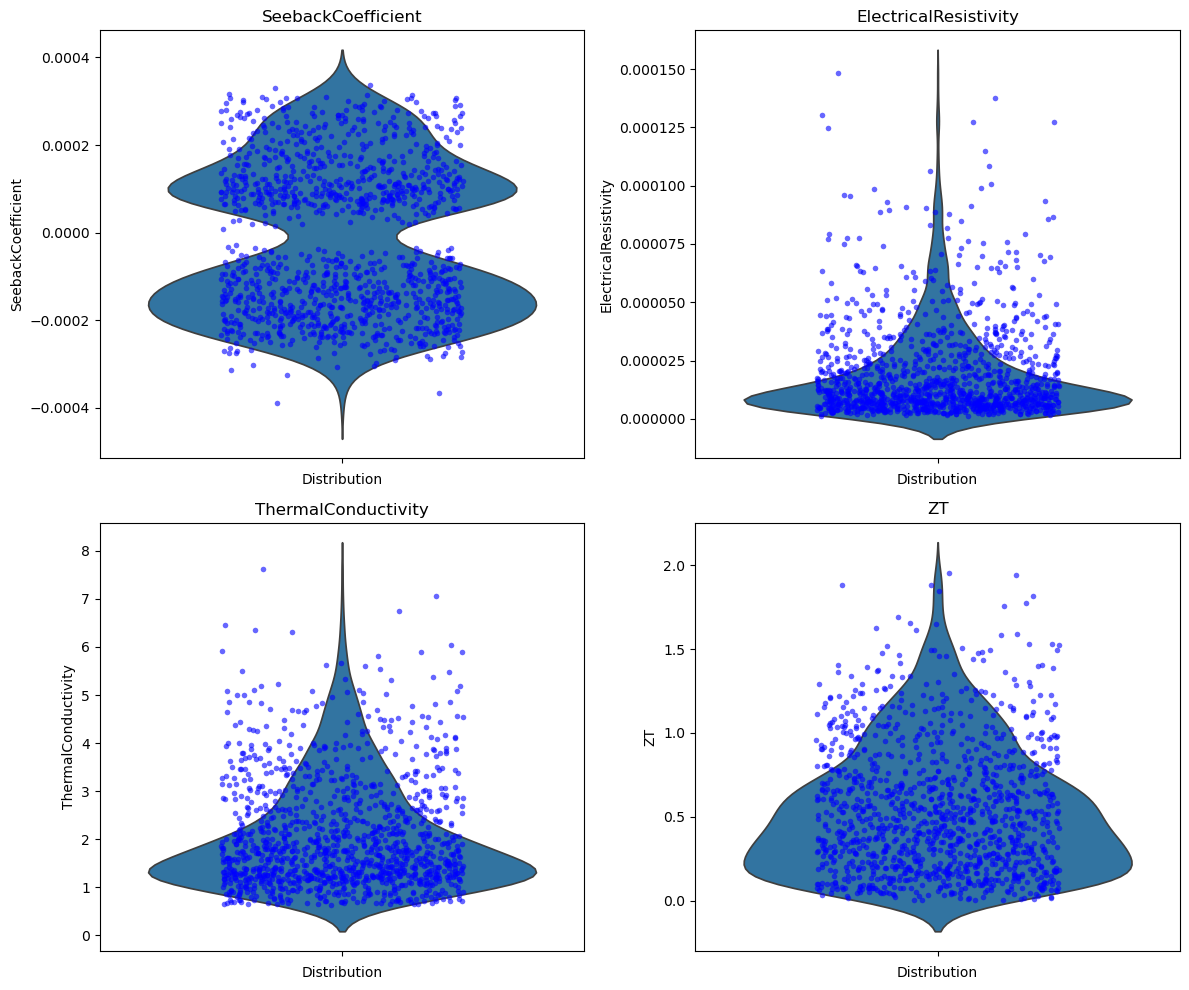

In [81]:
# plotting of each column of the cleaned Data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Data.csv")

columns = [
    "SeebackCoefficient",
    "ElectricalResistivity",
    "ThermalConductivity",
    "ZT"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(12,10)
)

for ax, col in zip(axes.flatten(), columns):
    sns.violinplot(
        y=df[col],
        inner= None,
        ax=ax
    )

    sns.stripplot(
        y=df[col],
        color="blue",
        size=4,
        alpha=0.6,
        jitter=0.25,
        ax=ax
    )

    ax.set_title(col)
    ax.set_xlabel("Distribution")
plt.tight_layout()
plt.savefig("violin_plot.png")
plt.show()

In [82]:
#consistency check of ZT 
import pandas as pd

df = pd.read_csv("Data.csv")

In [83]:
df = df.rename(columns={"ZT": "Recorded_ZT"})
df

,Temperature,Formula,SeebackCoefficient,ElectricalResistivity,ThermalConductivity,Recorded_ZT
0,350,Pb0.7Mn0.3Te1Na0.04,0.000186,0.000028,1.586099,0.276253
1,400,Pb0.7Mn0.3Te1Na0.04,0.000216,0.000032,1.412398,0.420050
2,450,Pb0.7Mn0.3Te1Na0.04,0.000243,0.000037,1.284120,0.563897
3,500,Pb0.7Mn0.3Te1Na0.04,0.000268,0.000044,1.168095,0.689989
4,550,Pb0.7Mn0.3Te1Na0.04,0.000289,0.000054,1.064337,0.799702
...,...,...,...,...,...,...
1208,550,Na0.015Pb0.955Cd0.03Te1,0.000197,0.000015,1.490776,0.982589
1209,600,Na0.015Pb0.955Cd0.03Te1,0.000218,0.000018,1.331080,1.228149
1210,650,Na0.015Pb0.955Cd0.03Te1,0.000234,0.000020,1.209305,1.438621
1211,700,Na0.015Pb0.955Cd0.03Te1,0.000242,0.000023,1.113275,1.587491


In [84]:
df["Calculated_ZT"] = (df["SeebackCoefficient"] **2/(df["ElectricalResistivity"]*df["ThermalConductivity"]))*df["Temperature"]

In [85]:
df

,Temperature,Formula,SeebackCoefficient,ElectricalResistivity,ThermalConductivity,Recorded_ZT,Calculated_ZT
0,350,Pb0.7Mn0.3Te1Na0.04,0.000186,0.000028,1.586099,0.276253,0.276253
1,400,Pb0.7Mn0.3Te1Na0.04,0.000216,0.000032,1.412398,0.420050,0.420050
2,450,Pb0.7Mn0.3Te1Na0.04,0.000243,0.000037,1.284120,0.563897,0.563897
3,500,Pb0.7Mn0.3Te1Na0.04,0.000268,0.000044,1.168095,0.689989,0.689989
4,550,Pb0.7Mn0.3Te1Na0.04,0.000289,0.000054,1.064337,0.799702,0.799702
...,...,...,...,...,...,...,...
1208,550,Na0.015Pb0.955Cd0.03Te1,0.000197,0.000015,1.490776,0.982589,0.982589
1209,600,Na0.015Pb0.955Cd0.03Te1,0.000218,0.000018,1.331080,1.228149,1.228149
1210,650,Na0.015Pb0.955Cd0.03Te1,0.000234,0.000020,1.209305,1.438621,1.438621
1211,700,Na0.015Pb0.955Cd0.03Te1,0.000242,0.000023,1.113275,1.587491,1.587491


In [86]:
df = df[
    abs(df["Calculated_ZT"] - df["Recorded_ZT"])
    <= (0.1 * df["Recorded_ZT"])
]
df

,Temperature,Formula,SeebackCoefficient,ElectricalResistivity,ThermalConductivity,Recorded_ZT,Calculated_ZT
0,350,Pb0.7Mn0.3Te1Na0.04,0.000186,0.000028,1.586099,0.276253,0.276253
1,400,Pb0.7Mn0.3Te1Na0.04,0.000216,0.000032,1.412398,0.420050,0.420050
2,450,Pb0.7Mn0.3Te1Na0.04,0.000243,0.000037,1.284120,0.563897,0.563897
3,500,Pb0.7Mn0.3Te1Na0.04,0.000268,0.000044,1.168095,0.689989,0.689989
4,550,Pb0.7Mn0.3Te1Na0.04,0.000289,0.000054,1.064337,0.799702,0.799702
...,...,...,...,...,...,...,...
1208,550,Na0.015Pb0.955Cd0.03Te1,0.000197,0.000015,1.490776,0.982589,0.982589
1209,600,Na0.015Pb0.955Cd0.03Te1,0.000218,0.000018,1.331080,1.228149,1.228149
1210,650,Na0.015Pb0.955Cd0.03Te1,0.000234,0.000020,1.209305,1.438621,1.438621
1211,700,Na0.015Pb0.955Cd0.03Te1,0.000242,0.000023,1.113275,1.587491,1.587491


* Here, 1180 rows are there for which the difference between calculated and recorded ZT value is less than 10%.
* So, 1180 values are consistent with each other in terms of there recorded and calculated values.

In [87]:
duplicates = (
    df.groupby(['Formula', 'Temperature'])['Calculated_ZT']
      .nunique()
      .reset_index()
)

duplicates = duplicates[duplicates['Calculated_ZT'] > 1]

print(duplicates) 

Empty DataFrame
Columns: [Formula, Temperature, Calculated_ZT]
Index: []


* It shows there are no such micro structural differences exist.

In [89]:
len(df)

1180

In [90]:
df

,Temperature,Formula,SeebackCoefficient,ElectricalResistivity,ThermalConductivity,Recorded_ZT,Calculated_ZT
0,350,Pb0.7Mn0.3Te1Na0.04,0.000186,0.000028,1.586099,0.276253,0.276253
1,400,Pb0.7Mn0.3Te1Na0.04,0.000216,0.000032,1.412398,0.420050,0.420050
2,450,Pb0.7Mn0.3Te1Na0.04,0.000243,0.000037,1.284120,0.563897,0.563897
3,500,Pb0.7Mn0.3Te1Na0.04,0.000268,0.000044,1.168095,0.689989,0.689989
4,550,Pb0.7Mn0.3Te1Na0.04,0.000289,0.000054,1.064337,0.799702,0.799702
...,...,...,...,...,...,...,...
1208,550,Na0.015Pb0.955Cd0.03Te1,0.000197,0.000015,1.490776,0.982589,0.982589
1209,600,Na0.015Pb0.955Cd0.03Te1,0.000218,0.000018,1.331080,1.228149,1.228149
1210,650,Na0.015Pb0.955Cd0.03Te1,0.000234,0.000020,1.209305,1.438621,1.438621
1211,700,Na0.015Pb0.955Cd0.03Te1,0.000242,0.000023,1.113275,1.587491,1.587491


In [99]:
# now we need the clean data of only formula, temperature and ZT value(recorded)
df_clean= df.drop(["SeebackCoefficient", "ElectricalResistivity","ThermalConductivity","Calculated_ZT"], axis=1)

In [100]:
df_clean


,Temperature,Formula,Recorded_ZT
0,350,Pb0.7Mn0.3Te1Na0.04,0.276253
1,400,Pb0.7Mn0.3Te1Na0.04,0.420050
2,450,Pb0.7Mn0.3Te1Na0.04,0.563897
3,500,Pb0.7Mn0.3Te1Na0.04,0.689989
4,550,Pb0.7Mn0.3Te1Na0.04,0.799702
...,...,...,...
1208,550,Na0.015Pb0.955Cd0.03Te1,0.982589
1209,600,Na0.015Pb0.955Cd0.03Te1,1.228149
1210,650,Na0.015Pb0.955Cd0.03Te1,1.438621
1211,700,Na0.015Pb0.955Cd0.03Te1,1.587491


In [102]:
df_clean = df_clean.rename(columns={"Recorded_ZT":"ZT"})

In [103]:
df_clean

,Temperature,Formula,ZT
0,350,Pb0.7Mn0.3Te1Na0.04,0.276253
1,400,Pb0.7Mn0.3Te1Na0.04,0.420050
2,450,Pb0.7Mn0.3Te1Na0.04,0.563897
3,500,Pb0.7Mn0.3Te1Na0.04,0.689989
4,550,Pb0.7Mn0.3Te1Na0.04,0.799702
...,...,...,...
1208,550,Na0.015Pb0.955Cd0.03Te1,0.982589
1209,600,Na0.015Pb0.955Cd0.03Te1,1.228149
1210,650,Na0.015Pb0.955Cd0.03Te1,1.438621
1211,700,Na0.015Pb0.955Cd0.03Te1,1.587491


In [106]:
df_clean.to_csv("/home/8e7da375-1215-4ce7-8157-c0b4225d40b7/Main_Project/Cleaned_Data.csv", index = False) 